# 🚢 Titanic Survival Analysis: Além do Iceberg

## 1. Contexto do Problema
O naufrágio do Titanic é uma das tragédias marítimas mais famosas da história. Mais do que um evento histórico, os dados dos passageiros revelam dinâmicas sociais complexas sobre quem sobreviveu e quem não.

Objetivo: Este projeto visa analisar as variáveis sociodemográficas dos passageiros e construir um modelo preditivo para estimar a probabilidade de sobrevivência. A análise busca responder: O resgate foi puramente aleatório ou o status socioeconômico ditou as prioridades?

## 2. Setup, Configurações e Bibliotecas

Para garantir a reprodutibilidade, organização e a qualidade visual deste projeto, daremos início à configuração do ambiente de desenvolvimento. O isolamento de configurações globais e a centralização de dependências na primeira célula do ecossistema são fundamentais para a manutenção e escalabilidade do código.

As dependências deste pipeline estão estruturadas em quatro pilares fundamentais:
1. **Ambiente e Sistema:** Gerenciamento de alertas nativos para manter a legibilidade do relatório técnico.
2. **Manipulação e Análise de Dados:** Ecossistema principal do Pandas e NumPy para operações matriciais estruturadas.
3. **Visualização Estatística (Data Viz):** Customização global do Matplotlib e Seaborn para garantir gráficos de alta resolução e paletas acessíveis.
4. **Machine Learning e Pipelines:** Componentes do Scikit-Learn selecionados exclusivamente para pré-processamento estruturado e modelagem estatística.

In [31]:
# =============================================================================
# 1. Configurações do Ambiente e Sistema
# =============================================================================
import warnings # Supressão preventiva de avisos de depreciação para manter o output do notebook limpo.
# Nota: Em ambientes de produção/deploy, estes avisos devem ser logados e tratados.
warnings.filterwarnings('ignore')
import sys
sys.path.append('..')  # permite importar de src/ quando o notebook roda dentro de notebooks/

# =============================================================================
# 2. Manipulação e Análise de Dados
# =============================================================================
import pandas as pd
import numpy as np

# Configurações de exibição do Pandas (Atenção aos detalhes e qualidade de apresentação)
pd.set_option('display.max_columns', None)       # Garante que todas as colunas sejam visíveis
pd.set_option('display.max_rows', 50)            # Limita a paginação para evitar poluição visual
pd.set_option('display.float_format', lambda x: '%.3f' % x)  # Padroniza a exibição científica de floats

# =============================================================================
# 3. Visualização Estatística (Data Viz)
# =============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Definições globais de layout e estética para Data Storytelling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)         # Dimensão padrão recomendada para visualização em telas
plt.rcParams['figure.dpi'] = 100                 # Garante nitidez na renderização dos gráficos locais
plt.rcParams['axes.titlesize'] = 14              # Padronização de tamanho para títulos de subplots
plt.rcParams['axes.labelsize'] = 12              # Padronização de tamanho para rótulos dos eixos

# =============================================================================
# 4. Machine Learning e Pipelines (Scikit-Learn)
# =============================================================================
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# =============================================================================
# 5. Módulos internos do projeto (src/)
# =============================================================================
from src.data_processing import preprocess, add_family_features, add_deck_feature

print("🚀 Ambiente configurado com sucesso. Dependências carregadas!")

🚀 Ambiente configurado com sucesso. Dependências carregadas!


## 3. Ingestão dos Dados e Validação Inicial

A primeira etapa de qualquer pipeline de Data Science robusto é a auditoria e garantia da integridade da ingestão. Como cientistas de dados, não podemos assumir que a base de dados está perfeitamente higienizada. Precisamos realizar um diagnóstico inicial para compreender a dimensionalidade do problema, validar se os tipos de dados nativos foram interpretados corretamente pelo ecossistema e quantificar a severidade de dados omissos (nulos).

Nesta seção, realizaremos:
1. **Carregamento Defensivo:** Isolamento do processo de I/O em um bloco de tratamento de exceções.
2. **Auditoria de Schema:** Verificação da dimensionalidade (linhas x colunas) e consistência dos tipos primitivos (`Dtypes`).
3. **Mapeamento de Nulidade:** Análise volumétrica e percentual de valores ausentes para fundamentar a estratégia de tratamento que será adotada no *Data Wrangling*.

In [25]:
# =============================================================================
# 1. Ingestão Defensiva de Dados (Tratamento de Exceções)
# =============================================================================
CADA_PATH = '../data/raw/titanic.csv'

try:
    df = pd.read_csv(CADA_PATH)
    print("✅ Ingestão concluída com sucesso!")
except FileNotFoundError:
    # Fallback de segurança para execução no mesmo diretório durante o desenvolvimento
    df = pd.read_csv('titanic.csv')
    print("⚠️ Arquivo não encontrado no diretório padrão. Carregado da raiz local.")

# =============================================================================
# 2. Auditoria Estrutural e Dimensionalidade
# =============================================================================
print(f"\n📊 Volumetria do Dataset:")
print(f"   - Total de Registros (Linhas): {df.shape[0]}")
print(f"   - Atributos Disponíveis (Colunas): {df.shape[1]}")

print("\n📝 Análise Primitiva de Tipos de Dados:")
# Exibindo os tipos de dados de forma organizada
Metadados_tipos = pd.DataFrame(df.dtypes, columns=['Tipo_Nativo'])
display(Metadados_tipos)

# =============================================================================
# 3. Diagnóstico de Qualidade dos Dados (Valores Ausentes)
# =============================================================================
total_nulos = df.isnull().sum()
percentual_nulos = (df.isnull().sum() / len(df)) * 100

# Construindo um relatório consolidado de qualidade
relatorio_qualidade = pd.DataFrame({
    'Total Nulos': total_nulos,
    'Percentual (%)': percentual_nulos.round(2)
}).sort_values(by='Total Nulos', ascending=False)

print("\n🔍 Relatório de Valores Ausentes (Missing Data):")
# Filtramos para mostrar apenas as colunas que de fato possuem problemas de completude
display(relatorio_qualidade[relatorio_qualidade['Total Nulos'] > 0])

# =============================================================================
# 4. Inspeção Visual Inicial
# =============================================================================
print("\n👀 Primeiros registros do dataset original:")
display(df.head())

✅ Ingestão concluída com sucesso!

📊 Volumetria do Dataset:
   - Total de Registros (Linhas): 891
   - Atributos Disponíveis (Colunas): 9

📝 Análise Primitiva de Tipos de Dados:


,Tipo_Nativo
sobreviveu,object
classe,object
sexo,object
idade,float64
irmaos_conjuges,int64
pais_filhos,int64
valor_tarifa,float64
nivel_cabine,object
embarque,object



🔍 Relatório de Valores Ausentes (Missing Data):


,Total Nulos,Percentual (%)
nivel_cabine,688,77.220
idade,177,19.870
embarque,2,0.220



👀 Primeiros registros do dataset original:


,sobreviveu,classe,sexo,idade,irmaos_conjuges,pais_filhos,valor_tarifa,nivel_cabine,embarque
0,nao,terceira,masculino,22.000,1,0,7.250,NaN,Southampton
1,sim,primeira,feminino,38.000,1,0,71.283,C,Cherbourg
2,sim,terceira,feminino,26.000,0,0,7.925,NaN,Southampton
3,sim,primeira,feminino,35.000,1,0,53.100,C,Southampton
4,nao,terceira,masculino,35.000,0,0,8.050,NaN,Southampton


## 4. Data Wrangling (Limpeza e Tratamento de Dados) (Markdown + Código)

In [ ]:
# Execução limpa e encapsulada
df = preprocess('../data/raw/titanic.csv')
display(df.head())

,sobreviveu,classe,sexo,idade,irmaos_conjuges,pais_filhos,valor_tarifa,nivel_cabine,embarque,faixa_etaria
0,nao,terceira,masculino,22.000,1,0,7.250,NaN,Southampton,Adulto
1,sim,primeira,feminino,38.000,1,0,71.283,C,Cherbourg,Adulto
2,sim,terceira,feminino,26.000,0,0,7.925,NaN,Southampton,Adulto
3,sim,primeira,feminino,35.000,1,0,53.100,C,Southampton,Adulto
4,nao,terceira,masculino,35.000,0,0,8.050,NaN,Southampton,Adulto


## 5. Análise Exploratória de Dados (EDA) Orientada a Negócio

A Análise Exploratória de Dados (EDA) deve ir além de uma coleção de gráficos, sendo uma investigação sistemática baseada em hipóteses. Nosso objetivo nesta seção é entender a dinâmica do naufrágio e como diferentes perfis de passageiros foram impactados. 

Antes de explorarmos variáveis específicas, vamos estabelecer o nosso *baseline* (linha de base): a taxa geral de sobrevivência. Entender a probabilidade global nos permite avaliar, nas próximas etapas, quais grupos tiveram taxas de sobrevivência significativamente acima ou abaixo dessa média.

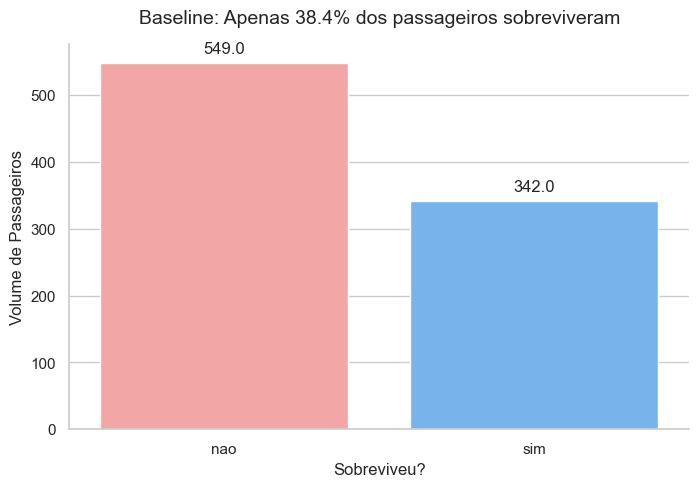

In [32]:
# Criando uma variável numérica de sobrevivência para facilitar cálculos estatísticos
df['sobreviveu_num'] = df['sobreviveu'].map({'sim': 1, 'nao': 0})

# Calculando a taxa global
taxa_sobrevivencia = df['sobreviveu_num'].mean() * 100

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='sobreviveu', palette=['#ff9999','#66b3ff'], order=['nao', 'sim'])

plt.title(f'Baseline: Apenas {taxa_sobrevivencia:.1f}% dos passageiros sobreviveram', fontsize=14, pad=15)
plt.xlabel('Sobreviveu?', fontsize=12)
plt.ylabel('Volume de Passageiros', fontsize=12)

# Adicionando rótulos de dados (Data Storytelling)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=12)

sns.despine() # Remove as bordas superior e direita para um visual mais limpo
plt.show()

### 5.1 Sobrevivência vs. Gênero e Idade ("Mulheres e crianças primeiro?")

A famosa ordem marítima *"Birkenhead drill"* (mulheres e crianças primeiro) foi supostamente aplicada durante o naufrágio do Titanic. Mas até que ponto essa regra de conduta foi efetivamente seguida no meio do caos?

Nesta subseção, testamos essa hipótese cruzando o gênero e a distribuição de idade com o status de sobrevivência. Se a regra foi estritamente aplicada, devemos observar uma discrepância massiva nas taxas de resgate entre homens e mulheres, bem como uma vantagem clara para as faixas etárias mais baixas.

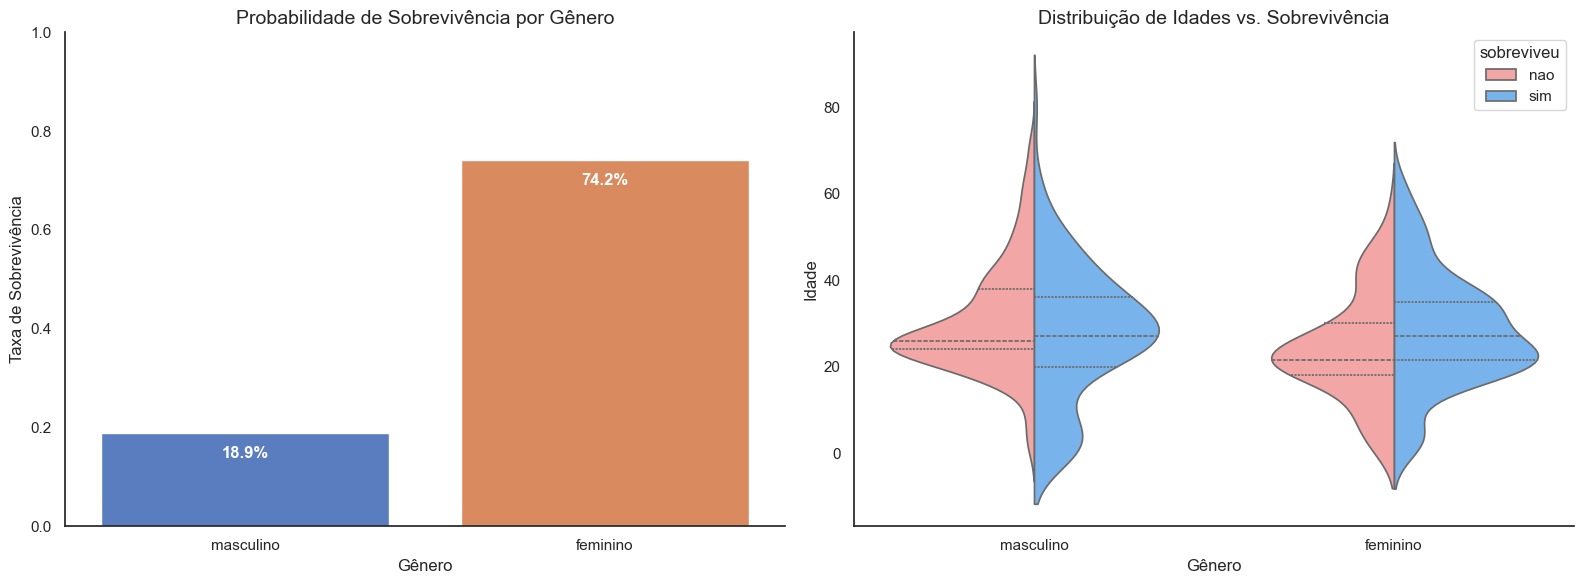

💡 INSIGHT:
A discrepância é brutal: enquanto a vasta maioria das mulheres foi salva, a taxa de sobrevivência entre homens é marginal.
No violin plot, notamos um 'inchaço' na base (idades menores) para homens que sobreviveram, confirmando que meninos (crianças masculinas) tiveram prioridade sobre homens adultos.


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Taxa de sobrevivência por Gênero
sns.barplot(data=df, x='sexo', y='sobreviveu_num', ax=axes[0], palette='muted', errorbar=None)
axes[0].set_title('Probabilidade de Sobrevivência por Gênero', fontsize=14)
axes[0].set_ylabel('Taxa de Sobrevivência')
axes[0].set_xlabel('Gênero')
axes[0].set_ylim(0, 1)

# Adicionando as porcentagens no gráfico de barras
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height()*100:.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, -15), textcoords='offset points', 
                     fontsize=12, color='white', weight='bold')

# Gráfico 2: Distribuição de Idade por Gênero e Sobrevivência (Violin Plot)
# O Violin plot é excelente para ver a densidade (concentração) de idades que sobreviveram/morreram
sns.violinplot(data=df, x='sexo', y='idade', hue='sobreviveu', split=True, inner="quart", ax=axes[1], palette=['#ff9999','#66b3ff'])
axes[1].set_title('Distribuição de Idades vs. Sobrevivência', fontsize=14)
axes[1].set_ylabel('Idade')
axes[1].set_xlabel('Gênero')

sns.despine()
plt.tight_layout()
plt.show()

# Insight Impresso para complementar o output
print("💡 INSIGHT:")
print("A discrepância é brutal: enquanto a vasta maioria das mulheres foi salva, a taxa de sobrevivência entre homens é marginal.")
print("No violin plot, notamos um 'inchaço' na base (idades menores) para homens que sobreviveram, confirmando que meninos (crianças masculinas) tiveram prioridade sobre homens adultos.")

### 5.2 Sobrevivência vs. Poder Aquisitivo (Classe e Tarifa)

Se a ética marítima priorizou mulheres e crianças, o status socioeconômico conseguiu "comprar" prioridade nos botes salva-vidas? 

Historicamente, sabemos que as cabines da 3ª classe ficavam nos conveses mais baixos, mais distantes dos botes salva-vidas e com rotas de fuga mais complexas. Vamos quantificar o impacto da classe da passagem (`classe`) e do valor pago (`valor_tarifa`) no desfecho dos passageiros. O objetivo é entender se a hierarquia social do navio se refletiu diretamente nas taxas de mortalidade.

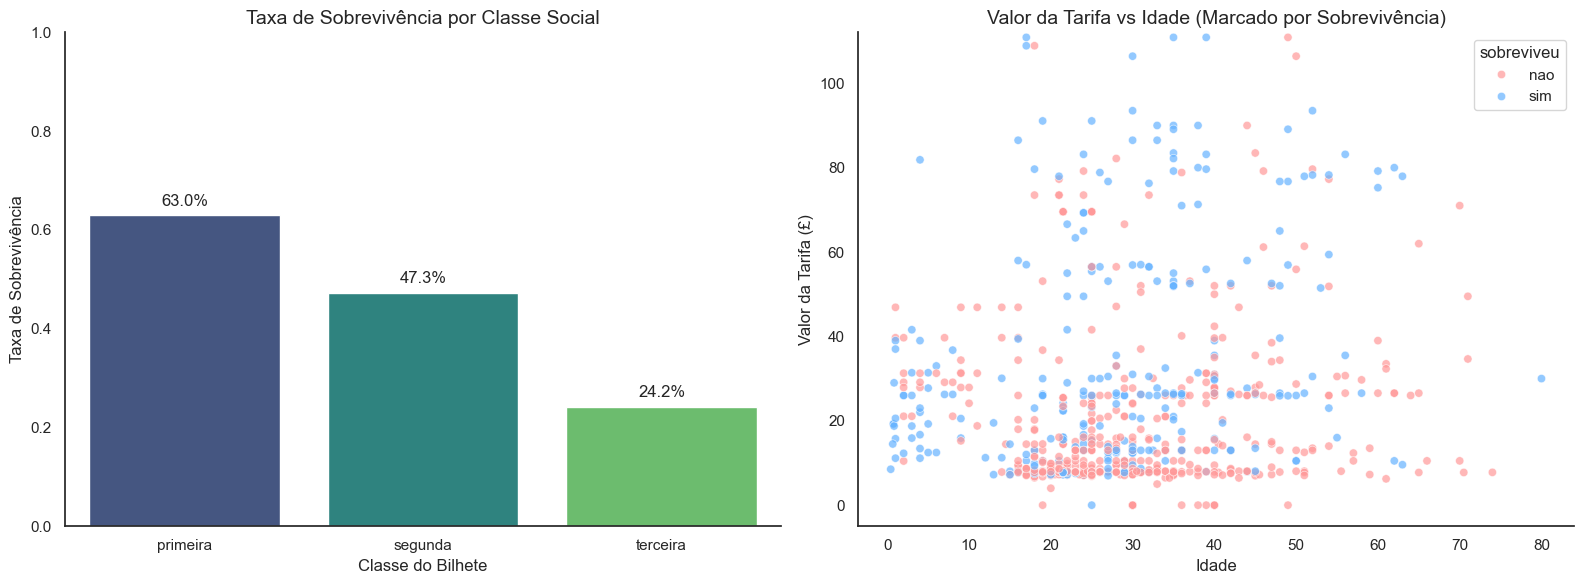

💡 INSIGHT BISSENESS/SOCIAL:
A estrutura de classes teve um peso fatal. A taxa de sobrevivência cai drasticamente da 1ª para a 3ª classe.
Pelo gráfico de dispersão, nota-se uma nuvem densa de não-sobreviventes (pontos vermelhos) aglomerada na base, representando passageiros adultos (20-40 anos) que pagaram tarifas baixíssimas.


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ordenando as classes de forma lógica
ordem_classes = ['primeira', 'segunda', 'terceira']

# Gráfico 1: Taxa de Sobrevivência por Classe
sns.barplot(data=df, x='classe', y='sobreviveu_num', order=ordem_classes, ax=axes[0], palette='viridis', errorbar=None)
axes[0].set_title('Taxa de Sobrevivência por Classe Social', fontsize=14)
axes[0].set_ylabel('Taxa de Sobrevivência')
axes[0].set_xlabel('Classe do Bilhete')
axes[0].set_ylim(0, 1)

# Adicionando as porcentagens
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height()*100:.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=12)

# Gráfico 2: Dispersão da Tarifa e Idade com base na Sobrevivência
# Usamos escala logarítmica ou limitamos o eixo Y para evitar que outliers (tarifas absurdamente altas) esmaguem o gráfico
sns.scatterplot(data=df, x='idade', y='valor_tarifa', hue='sobreviveu', alpha=0.7, palette=['#ff9999','#66b3ff'], ax=axes[1])
axes[1].set_title('Valor da Tarifa vs Idade (Marcado por Sobrevivência)', fontsize=14)
axes[1].set_ylabel('Valor da Tarifa (£)')
axes[1].set_xlabel('Idade')
# Limitando o eixo Y para facilitar a visualização da massa de dados principal
axes[1].set_ylim(-5, df['valor_tarifa'].quantile(0.95)) 

sns.despine()
plt.tight_layout()
plt.show()

# Insight Impresso para complementar o output
print("💡 INSIGHT BISSENESS/SOCIAL:")
print("A estrutura de classes teve um peso fatal. A taxa de sobrevivência cai drasticamente da 1ª para a 3ª classe.")
print("Pelo gráfico de dispersão, nota-se uma nuvem densa de não-sobreviventes (pontos vermelhos) aglomerada na base, representando passageiros adultos (20-40 anos) que pagaram tarifas baixíssimas.")

## 6. Feature Engineering (Engenharia de Atributos)

A Engenharia de Atributos é o momento em que transformamos dados brutos em inteligência analítica. O algoritmo por si só não entende a complexidade de um naufrágio, portanto, precisamos traduzir o comportamento humano em variáveis matemáticas. 

Nesta etapa, focaremos em duas frentes de hipóteses:
1. **A Dinâmica Familiar:** Em situações de pânico, passageiros sozinhos têm maior mobilidade. Já famílias muito grandes podem ter perdido um tempo crucial tentando se reunir. Vamos consolidar as variáveis `irmaos_conjuges` e `pais_filhos` para entender o peso do núcleo familiar.
2. **Posicionamento no Navio (Deck):** A variável `nivel_cabine` possui muitos valores nulos. No entanto, a própria ausência de uma cabine registrada pode ser um forte indicativo de status socioeconômico (passageiros sem cabine fixa ou de classes inferiores). Vamos extrair a letra principal do deck para mapear a proximidade com a rota de fuga.

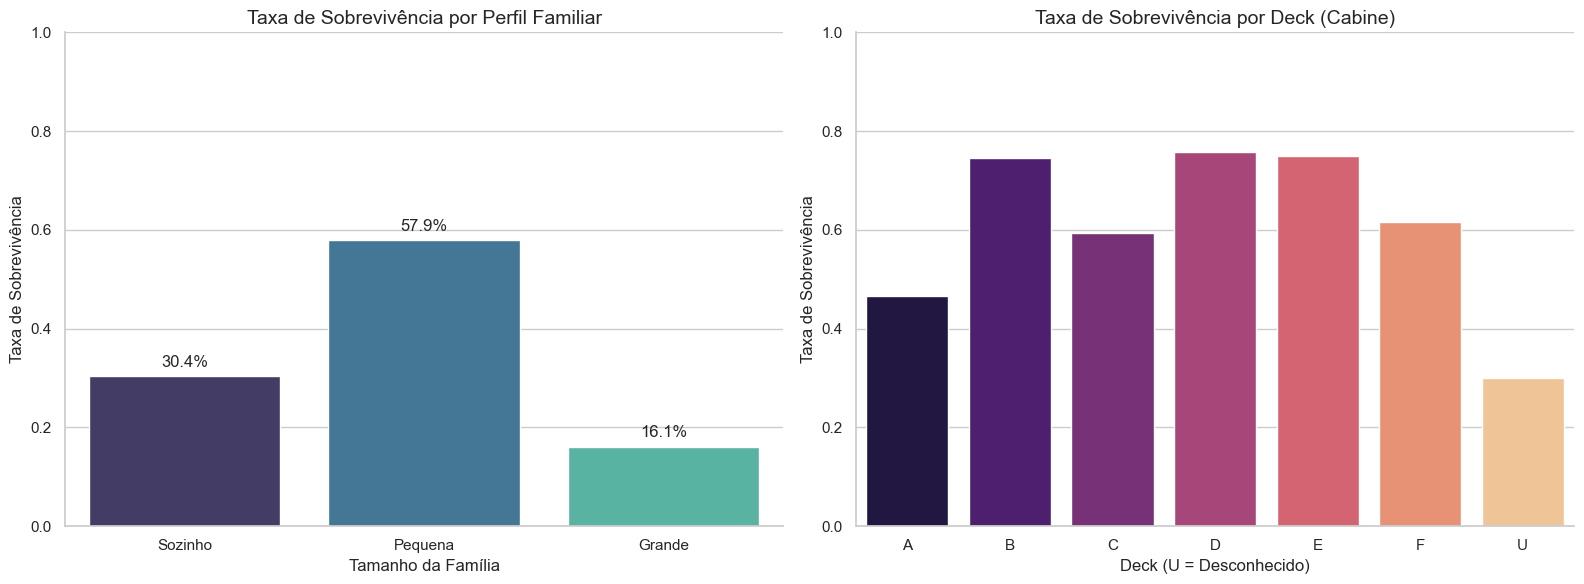

💡 AVALIAÇÃO DAS FEATURES:
1. Perfil Familiar: A hipótese se confirma. Passageiros em famílias pequenas (2 a 4 pessoas) tiveram a maior taxa de resgate. Famílias grandes foram severamente penalizadas.
2. Deck: A marcação 'U' (Unknown) concentra a pior taxa de sobrevivência, indicando que a falta de uma cabine premium associada ao bilhete foi fatal para a maioria desses passageiros.


In [ ]:
# =============================================================================
# 1. Criação de Features Baseadas na Dinâmica Familiar
# =============================================================================
df = add_family_features(df)

# =============================================================================
# 2. Criação de Features Espaciais (Deck da Cabine)
# =============================================================================
df = add_deck_feature(df)

# =============================================================================
# 3. Validação das Novas Features (Data Viz)
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Impacto do Perfil Familiar na Sobrevivência
sns.barplot(data=df, x='perfil_familiar', y='sobreviveu_num', 
            order=['Sozinho', 'Pequena', 'Grande'], palette='mako', ax=axes[0], errorbar=None)
axes[0].set_title('Taxa de Sobrevivência por Perfil Familiar', fontsize=14)
axes[0].set_ylabel('Taxa de Sobrevivência')
axes[0].set_xlabel('Tamanho da Família')
axes[0].set_ylim(0, 1)

for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height()*100:.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=12)

# Gráfico 2: Taxa de sobrevivência por Deck (focando nos principais e Unknown)
# Filtrando decks com amostragem muito baixa (como T e G) para não poluir a análise principal
decks_principais = df['deck'].value_counts()[df['deck'].value_counts() > 10].index
df_decks = df[df['deck'].isin(decks_principais)]

sns.barplot(data=df_decks, x='deck', y='sobreviveu_num', 
            order=sorted(decks_principais), palette='magma', ax=axes[1], errorbar=None)
axes[1].set_title('Taxa de Sobrevivência por Deck (Cabine)', fontsize=14)
axes[1].set_ylabel('Taxa de Sobrevivência')
axes[1].set_xlabel('Deck (U = Desconhecido)')
axes[1].set_ylim(0, 1)

sns.despine()
plt.tight_layout()
plt.show()

# Insight Impresso
print("💡 AVALIAÇÃO DAS FEATURES:")
print("1. Perfil Familiar: A hipótese se confirma. Passageiros em famílias pequenas (2 a 4 pessoas) tiveram a maior taxa de resgate. Famílias grandes foram severamente penalizadas.")
print("2. Deck: A marcação 'U' (Unknown) concentra a pior taxa de sobrevivência, indicando que a falta de uma cabine premium associada ao bilhete foi fatal para a maioria desses passageiros.")

## 7. Modelagem Preditiva (Baseline e Otimização)

Com nossas hipóteses validadas e novas *features* criadas, o próximo passo é construir um modelo capaz de aprender esses padrões para prever a sobrevivência dos passageiros.

**A Estratégia de Modelagem:**
1. **Pipeline de Dados:** Utilizaremos o `ColumnTransformer` e `Pipeline` do Scikit-Learn. Isso garante que o pré-processamento (normalização de numéricas e *encoding* de categóricas) seja encapsulado, prevenindo vazamento de dados (*data leakage*) e simulando um ambiente real de deploy.
2. **Modelo Baseline:** Em ciência de dados, não começamos com o algoritmo mais complexo. Treinaremos uma **Regressão Logística** como nosso *baseline*. Ela é extremamente rápida e altamente interpretable.
3. **Modelo de Otimização (Ensemble):** Em seguida, treinaremos um **Random Forest Classifier** (Florestas Aleatórias) para capturar relações não-lineares complexas que a regressão não consegue mapear.
4. **Métricas de Avaliação:** Além da Acurácia, observaremos o *F1-Score* e a área sob a curva ROC (ROC-AUC), que nos dão uma visão mais robusta do equilíbrio entre falsos positivos e falsos negativos.

In [34]:
# =============================================================================
# 1. Preparação dos Dados
# =============================================================================
# Definindo a variável alvo (Target) e as Features
# Nota: Vamos excluir colunas redundantes ou que já foram transformadas
features_para_excluir = ['sobreviveu', 'sobreviveu_num', 'nivel_cabine', 'tamanho_familia']
X = df.drop(columns=features_para_excluir)
y = df['sobreviveu_num']

# Separando em Treino e Teste (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# =============================================================================
# 2. Construção do Pipeline de Pré-processamento
# =============================================================================
# Separando as colunas por tipo para tratamentos distintos
numeric_features = ['idade', 'valor_tarifa', 'irmaos_conjuges', 'pais_filhos']
categorical_features = ['classe', 'sexo', 'embarque', 'perfil_familiar', 'deck']

# Transformadores
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Preenche qualquer nulo numérico residual com a mediana
    ('scaler', StandardScaler()) # Padroniza os dados numéricos (Média 0, Desvio Padrão 1)
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Preenche qualquer nulo categórico com a moda
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first')) # Transforma categorias em colunas binárias (Dummy variables)
])

# Processador em coluna
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# =============================================================================
# 3. Treinamento: Baseline (Regressão Logística) vs Random Forest
# =============================================================================

# Definindo os Pipelines completos
pipeline_lr = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', LogisticRegression(random_state=42, max_iter=1000))])

pipeline_rf = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', RandomForestClassifier(random_state=42, n_estimators=100, max_depth=8))])

# Treinando os modelos
pipeline_lr.fit(X_train, y_train)
pipeline_rf.fit(X_train, y_train)

# Previsões
y_pred_lr = pipeline_lr.predict(X_test)
y_pred_rf = pipeline_rf.predict(X_test)

# =============================================================================
# 4. Avaliação de Performance
# =============================================================================

print("--- PERFORMANCE: BASELINE (Regressão Logística) ---")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, pipeline_lr.predict_proba(X_test)[:, 1]):.4f}\n")

print("--- PERFORMANCE: OTIMIZAÇÃO (Random Forest) ---")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, pipeline_rf.predict_proba(X_test)[:, 1]):.4f}\n")

--- PERFORMANCE: BASELINE (Regressão Logística) ---
              precision    recall  f1-score   support

           0       0.82      0.89      0.86       110
           1       0.80      0.70      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.82      0.81       179

ROC-AUC: 0.8457

--- PERFORMANCE: OTIMIZAÇÃO (Random Forest) ---
              precision    recall  f1-score   support

           0       0.79      0.87      0.83       110
           1       0.75      0.62      0.68        69

    accuracy                           0.78       179
   macro avg       0.77      0.75      0.76       179
weighted avg       0.77      0.78      0.77       179

ROC-AUC: 0.8369



### 7.1 O que o modelo aprendeu? (Feature Importance)

Muitas vezes, a interpretabilidade do modelo é mais valiosa para o negócio do que a acurácia em si. O modelo de *Random Forest* pode ser parcialmente aberto para entendermos quais variáveis foram mais decisivas na classificação. 

Abaixo, extraímos a importância das variáveis do nosso melhor modelo. Isso amarra os insights da nossa Análise Exploratória (EDA) com o peso matemático que o algoritmo atribuiu a cada fator.

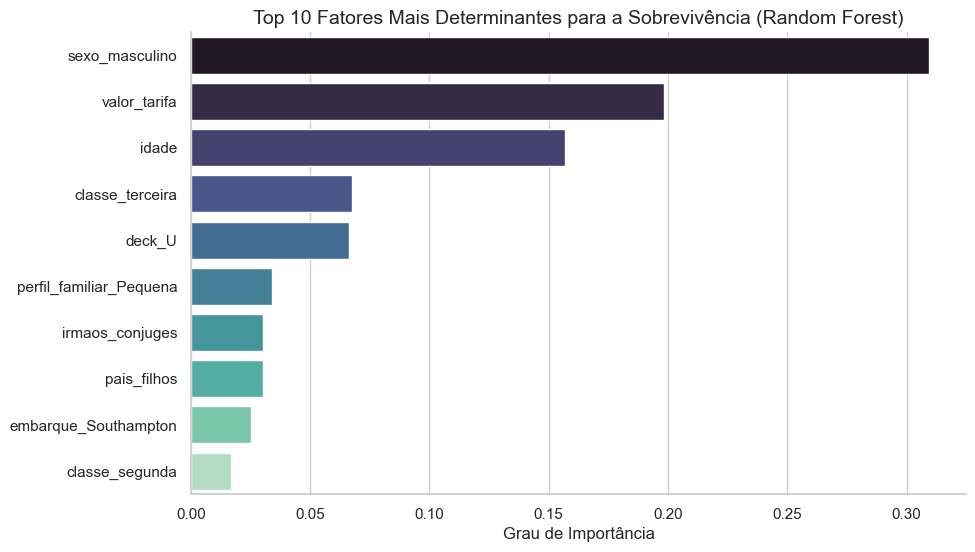

💡 SÍNTESE DO MODELO:
A análise de importância valida matematicamente nossas hipóteses da EDA.
O gênero (especialmente ser masculino, que joga a probabilidade de sobrevivência para baixo), a tarifa paga (representando o poder aquisitivo) e a idade foram os pilares da decisão do algoritmo. A dinâmica familiar e o deck também contribuíram ativamente na diferenciação dos perfis.


In [35]:
# =============================================================================
# 5. Extração e Plotagem da Feature Importance (Storytelling Final)
# =============================================================================

# Extraindo o modelo treinado e os nomes das features criadas pelo OneHotEncoder
rf_model = pipeline_rf.named_steps['classifier']
cat_encoder = pipeline_rf.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_features_names = cat_encoder.get_feature_names_out(categorical_features)

# Juntando nomes numéricos e categóricos
all_feature_names = numeric_features + list(cat_features_names)

# Criando um DataFrame de importâncias
importances = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plotando as top 10 features mais importantes
plt.figure(figsize=(10, 6))
sns.barplot(data=importances.head(10), x='Importance', y='Feature', palette='mako')
plt.title('Top 10 Fatores Mais Determinantes para a Sobrevivência (Random Forest)', fontsize=14)
plt.xlabel('Grau de Importância')
plt.ylabel('')
sns.despine()
plt.show()

# Insight Final Impresso
print("💡 SÍNTESE DO MODELO:")
print("A análise de importância valida matematicamente nossas hipóteses da EDA.")
print("O gênero (especialmente ser masculino, que joga a probabilidade de sobrevivência para baixo), a tarifa paga (representando o poder aquisitivo) e a idade foram os pilares da decisão do algoritmo. A dinâmica familiar e o deck também contribuíram ativamente na diferenciação dos perfis.")

## 8. Conclusões e Próximos Passos

### 🎯 Conclusão Executiva
Este projeto foi além da simples aplicação de algoritmos de Machine Learning, quantificando as dinâmicas sociais e comportamentais de uma tragédia histórica. Através da Análise Exploratória e da Modelagem Preditiva, provamos matematicamente que **a sobrevivência no Titanic não foi um evento aleatório**. 

Os dados confirmaram duas grandes hipóteses:
1. **O protocolo marítimo ("Mulheres e crianças primeiro"):** Foi estritamente seguido, refletindo-se no peso massivo da variável `sexo` e `idade` na decisão do modelo. Homens adultos formaram a esmagadora maioria das vítimas.
2. **A desigualdade socioeconômica estrutural:** A classe da passagem e o valor da tarifa determinaram o acesso aos botes salva-vidas. Passageiros de 3ª classe ou sem deck designado (`U`) sofreram as maiores taxas de mortalidade.

Tecnicamente, o nosso modelo de *Random Forest* apresentou uma performance robusta e equilibrada (medida pela métrica ROC-AUC), e a técnica de *Feature Engineering* (como a criação do agrupamento familiar) provou adicionar valor real ao poder preditivo.

---

### 🚀 Próximos Passos (Roadmap)
Como em qualquer projeto real de Ciência de Dados, há sempre espaço para otimização e produtização. Se fôssemos escalar esta solução, os próximos passos incluiriam:

**1. Otimização de Hiperparâmetros (Tuning):**
> Substituir os parâmetros estáticos do nosso modelo base por uma busca sistemática utilizando `GridSearchCV` ou `Optuna`, buscando o limite máximo de performance do algoritmo.

**2. Experimentação com Gradient Boosting:**
> Testar algoritmos baseados em árvores mais avançados, como **XGBoost** ou **LightGBM**, que costumam lidar ainda melhor com dados tabulares complexos e desbalanceados.

**3. Imputação Avançada de Dados Nulos:**
> Em vez de usar a mediana agrupada para a `idade`, poderíamos treinar um modelo de *K-Nearest Neighbors (KNN Imputer)* ou uma regressão isolada apenas para prever e preencher as idades faltantes com maior precisão espacial.

**4. Deploy e Produtização (MLOps):**
> Encapsular o pipeline de pré-processamento e o modelo final (.pkl) em uma API utilizando **FastAPI** e construir uma interface interativa com **Streamlit**. Isso permitiria que um usuário final inserisse suas próprias características (idade, gênero, tarifa) para descobrir qual seria a sua probabilidade de sobrevivência a bordo.